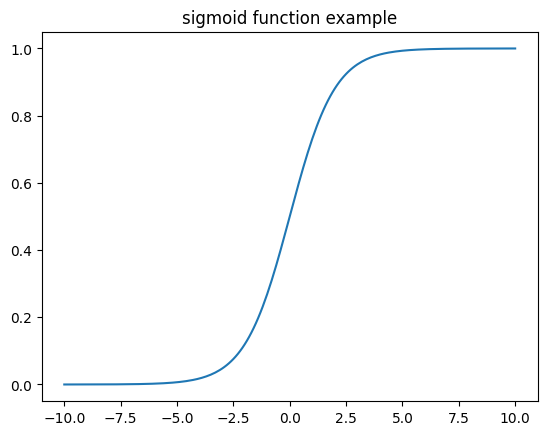

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 정의: 입력값을 0~1 사이로 변환하는 비선형 함수
def sigmoid(x):
    y = 1 / (1 + np.exp(-x))
    return y

# -10부터 10까지 0.1 간격의 입력값 생성
x_values = np.arange(-10, 10.1, 0.1)
y_values = []

# 각 입력값에 대해 시그모이드 함수값 계산
for x in x_values:
    y = sigmoid(x)
    y_values.append(y)

# 시그모이드 함수 곡선 시각화
plt.plot(x_values, y_values)
plt.title('sigmoid function example')
plt.show()

In [2]:
##공식 참고(단순 공식표)
import tensorflow as tf

# 시그모이드 확률(로지스틱 회귀의 예측 확률) 계산 함수
def prob(x, w, b):
    z = w * x + b  # 선형 결합: 입력 x, 가중치 w, 절편 b
    a = 1 / (1 + tf.math.exp(-z))  # 시그모이드 함수 적용
    return a

# 로지스틱 회귀의 손실 함수(이진 크로스엔트로피) 정의
def loss(w, b, x, y):
    a = prob(x, w, b)  # 예측 확률
    # 이진 크로스엔트로피: 실제값 y와 예측확률 a의 오차를 로그로 계산
    l = y * tf.math.log(a) + (1 - y) * tf.math.log(1 - a)
    # 평균 손실값의 음수(-)를 반환 (최소화가 목적)
    return -tf.reduce_mean(l)

/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# 파라미터 w, b에 대한 손실함수의 그래디언트(수식 기반 직접 계산)
def grad_w(w, b, x, y):
    a = prob(x, w, b)  # 예측 확률
    # (예측값 - 실제값) * 입력값의 평균: w에 대한 그래디언트
    return tf.reduce_mean((a - y) * x)

def grad_b(w, b, x, y):
    a = prob(x, w, b)  # 예측 확률
    # (예측값 - 실제값)의 평균: b에 대한 그래디언트
    return tf.reduce_mean(a - y)

# --- 데이터 값 직접 입력 (데이터가 적으므로 코드에 직접 기입) ---
x = tf.constant([1,2,3,4,5,6,7,8,9,10], dtype=tf.float32)
y = tf.constant([0,0,0,1,1,0,1,1,1,1], dtype=tf.float32)

# --- 파라미터 w, b의 초기값 설정 (학습을 통해 계속 변경될 값이므로 tf.Variable로 선언) ---
w = tf.Variable(0.2, dtype=tf.float32)
b = tf.Variable(-0.2, dtype=tf.float32)

0.534673 0.20131862 -0.20097609 -0.13186207 0.097608715
0.53440803 0.20256527 -0.2019629 -0.124664284 0.09868204
0.534159 0.20374483 -0.2029597 -0.117956236 0.0996798
0.53392375 0.20486183 -0.20396578 -0.111700535 0.100607656
0.5337006 0.20592047 -0.2049805 -0.10586343 0.101470694
0.533488 0.2069246 -0.20600323 -0.100413606 0.1022737
0.5332848 0.20787783 -0.20703344 -0.095323086 0.10302095
0.53308964 0.20878348 -0.2080706 -0.09056511 0.10371645
0.5329017 0.20964465 -0.20911424 -0.08611643 0.1043638
0.5327201 0.2104642 -0.2101639 -0.08195488 0.1049664
0.5325441 0.21124479 -0.21121918 -0.07806046 0.10552732
0.5323729 0.21198894 -0.21227968 -0.07441433 0.10604944
0.5322061 0.21269894 -0.21334504 -0.07099958 0.10653539
0.5320431 0.21337694 -0.21441491 -0.067800544 0.10698755
0.5318834 0.21402496 -0.21548899 -0.06480227 0.10740825
0.5317267 0.21464488 -0.21656698 -0.061991405 0.10779957
0.5315728 0.21523844 -0.21764861 -0.059355784 0.10816338
0.53142107 0.21580727 -0.21873362 -0.056883525 0

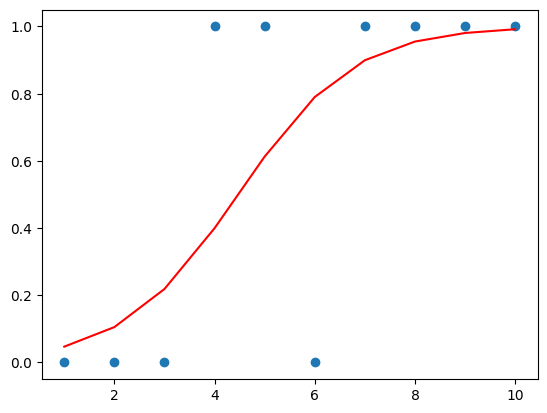

In [4]:
learning_rate = 0.01  # 학습률 설정

while True:
    h = loss(w, b, x, y)         # 현재 손실값 계산
    dw = grad_w(w, b, x, y)      # w에 대한 그래디언트 계산
    db = grad_b(w, b, x, y)      # b에 대한 그래디언트 계산

    # 경사하강법(gradient descent)으로 파라미터 업데이트
    w.assign_add(-dw * learning_rate)
    b.assign_add(-db * learning_rate)

    # 학습 과정 모니터링: 파라미터와 그래디언트 값 출력
    print(h.numpy(), w.numpy(), b.numpy(), dw.numpy(), db.numpy())

    # 그래디언트가 충분히 작아지면(수렴) 반복 종료
    if abs(dw) < 0.0001 and abs(db) < 0.0001:
        break

# 최종 파라미터와 손실값 출력
print("w, b =", w.numpy(), b.numpy())
print("loss =", loss(w, b, x, y).numpy())

# 모델 시각화: 실제 데이터와 예측 확률 곡선
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.plot(x, prob(x, w, b), color='red')
plt.show()

In [ ]:
#pip install scikit-learn
#pip install matplotlib
#pip install numpy

from sklearn.linear_model import LogisticRegression

# 입력 데이터(x)는 2차원 배열(샘플 수 x 특성 수)로, 타깃(y)은 1차원 배열로 준비
x = [[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]]
y = [0, 0, 0, 0, 1, 1, 0, 1, 1, 1]

# penalty='none' 옵션: 정규화(패널티) 없이 순수한 로지스틱 회귀 모델 학습
model = LogisticRegression(penalty=None).fit(x, y) # penalty='none' 대신 penalty=None 사용

# 학습된 모델로 예측값 출력
print('Predicted = ', model.predict(x))

# 학습된 가중치(w)와 절편(b) 추출
w = model.coef_
b = model.intercept_
print(w, b)

Predicted =  [0 0 0 0 0 1 1 1 1 1]
[[0.87969735]] [-4.83834448]


In [17]:
import pandas as pd
import kagglehub
#pip install kagglehub

# Kaggle에서 데이터셋 다운로드 (최신 버전)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
# print("Path to dataset files:", path)

# 기존 로컬 파일 읽기 코드 주석 처리
# df = pd.read_csv('creditcard.csv')

# KaggleHub로 받은 경로에서 파일 읽기 (예: creditcard.csv)
df = pd.read_csv(f"{path}/creditcard.csv")
#import pandas as pd

# 데이터 읽기 및 기본 정보 확인
#df = pd.read_csv('creditcard.csv')
print(df.columns)
print('# of rows =', len(df))
print('# of fraud rows =', len(df[df['Class'] == 1]))

# 입력 특성(feature)과 타깃(target) 분리
feature = df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8',
              'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16',
              'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24',
              'V25', 'V26', 'Amount']]
target = df['Class']

# 학습용/테스트용 데이터 분할 (테스트 데이터 30%)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.3)
print('# of test data =', len(y_test))

# 로지스틱 회귀 모델 학습 (정규화 없이, 반복횟수 충분히 설정)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty=None, max_iter=1000).fit(x_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = model.predict(x_test)

# 예측 성능 평가 (정밀도, 재현율, F1-score 등)
from sklearn.metrics import classification_report
print("<Classification Report>")
print(classification_report(y_test, y_pred))

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
# of rows = 284807
# of fraud rows = 492
# of test data = 85443
<Classification Report>
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85305
           1       0.79      0.57      0.66       138

    accuracy                           1.00     85443
   macro avg       0.89      0.79      0.83     85443
weighted avg       1.00      1.00      1.00     85443



/Users/juns/business_analytics/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
